In [1]:
import os
import shutil
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

2026-03-07 23:37:07.378996: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772926627.552658      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772926627.601097      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772926628.000674      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772926628.000724      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772926628.000727      55 computation_placer.cc:177] computation placer alr

In [2]:
import os

print(os.listdir("/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"))

['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Tomato_Late_blight', 'Potato___Early_blight', 'Tomato__Tomato_mosaic_virus']


In [3]:
import os
import shutil

source_dir = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"
target_dir = "/kaggle/working/tomato_dataset"

os.makedirs(target_dir, exist_ok=True)

for folder in os.listdir(source_dir):
    if "Tomato" in folder:
        shutil.copytree(
            os.path.join(source_dir, folder),
            os.path.join(target_dir, folder)
        )

print("Tomato dataset prepared successfully!")

Tomato dataset prepared successfully!


In [4]:
os.listdir("/kaggle/working/tomato_dataset")

['Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato_Late_blight',
 'Tomato_Bacterial_spot',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_Leaf_Mold',
 'Tomato_healthy',
 'Tomato_Septoria_leaf_spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Target_Spot',
 'Tomato_Early_blight']

In [5]:
classes = os.listdir(target_dir)
print("Classes:", classes)
print("Total Classes:", len(classes))

Classes: ['Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Late_blight', 'Tomato_Bacterial_spot', 'Tomato__Tomato_mosaic_virus', 'Tomato_Leaf_Mold', 'Tomato_healthy', 'Tomato_Septoria_leaf_spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Target_Spot', 'Tomato_Early_blight']
Total Classes: 10


In [8]:
IMG_SIZE = 224
BATCH_SIZE = 64

In [9]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    target_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    target_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

Found 16011 files belonging to 10 classes.
Using 12809 files for training.


I0000 00:00:1772926759.525792      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772926759.532001      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 16011 files belonging to 10 classes.
Using 3202 files for validation.


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

In [12]:
import tensorflow as tf

try:
    # Detect TPU
    resolver = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(resolver)
    tf.tpu.experimental.initialize_tpu_system(resolver)
    strategy = tf.distribute.TPUStrategy(resolver)
    print("TPU is ready")
except ValueError:
    strategy = tf.distribute.get_strategy()
    print("Running on CPU/GPU")

Running on CPU/GPU


In [13]:
print("Number of replicas:", strategy.num_replicas_in_sync)

Number of replicas: 1


In [14]:
with strategy.scope():
    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=(224,224,3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    model = tf.keras.Sequential([
        data_augmentation,
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
EPOCHS = 64

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/64


E0000 00:00:1772926802.236611      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1772926805.264859     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


201/201 ━━━━━━━━━━━━━━━━━━━━ 53s 184ms/step - accuracy: 0.3595 - loss: 2.0666 - val_accuracy: 0.7217 - val_loss: 1.0371
Epoch 2/64
201/201 ━━━━━━━━━━━━━━━━━━━━ 33s 164ms/step - accuracy: 0.6919 - loss: 0.9290 - val_accuracy: 0.8217 - val_loss: 0.6000
Epoch 3/64
201/201 ━━━━━━━━━━━━━━━━━━━━ 33s 165ms/step - accuracy: 0.7642 - loss: 0.7006 - val_accuracy: 0.8498 - val_loss: 0.4735
Epoch 4/64
201/201 ━━━━━━━━━━━━━━━━━━━━ 34s 168ms/step - accuracy: 0.8060 - loss: 0.5657 - val_accuracy: 0.8632 - val_loss: 0.4127
Epoch 5/64
201/201 ━━━━━━━━━━━━━━━━━━━━ 34s 169ms/step - accuracy: 0.8298 - loss: 0.5035 - val_accuracy: 0.8732 - val_loss: 0.3775
Epoch 6/64
201/201 ━━━━━━━━━━━━━━━━━━━━ 34s 171ms/step - accuracy: 0.8489 - loss: 0.4448 - val_accuracy: 0.8866 - val_loss: 0.3474
Epoch 7/64
201/201 ━━━━━━━━━━━━━━━━━━━━ 34s 171ms/step - accuracy: 0.8656 - loss: 0.4017 - val_accuracy: 0.8991 - val_loss: 0.3148
Epoch 8/64
201/201 ━━━━━━━━━━━━━━━━━━━━ 34s 171ms/step - accuracy: 0.8635 - loss: 0.3931 - val

In [17]:
model.save("/kaggle/working/plant_disease_model.keras")

In [18]:
import os
print(os.listdir("/kaggle/working"))

['plant_disease_efficientnet_model.h5', '.virtual_documents', 'tomato_dataset', 'plant_disease_model.keras']


In [19]:
loss, accuracy = model.evaluate(val_ds)

print("Final Validation Accuracy:", accuracy)
print("Final Validation Loss:", loss)

51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - accuracy: 0.9606 - loss: 0.1267
Final Validation Accuracy: 0.9550281167030334
Final Validation Loss: 0.1347893923521042


In [20]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
2/2 ━━━━━━━━

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[406   0   2   0   4   1   8   0   0   0]
 [  3 143   9   1   7   3  15   1   0   3]
 [  0   4 358   0   3   0   2   0   0   3]
 [  0   0   0 179   2   3   6   0   0   1]
 [  2   2   0   0 357   3   8   0   0   0]
 [  0   0   0   0   0 299  18   0   1   4]
 [  0   0   0   0   1   1 278   0   0   7]
 [  7   0   0   0   2   4   1 658   0   0]
 [  0   0   0   0   0   0   0   0  68   0]
 [  0   0   0   0   0   0   2   0   0 312]]


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       421
           1       0.96      0.77      0.86       185
           2       0.97      0.97      0.97       370
           3       0.99      0.94      0.96       191
           4       0.95      0.96      0.95       372
           5       0.95      0.93      0.94       322
           6       0.82      0.97      0.89       287
           7       1.00      0.98      0.99       672
           8       0.99      1.00      0.99        68
           9       0.95      0.99      0.97       314

    accuracy                           0.96      3202
   macro avg       0.95      0.95      0.95      3202
weighted avg       0.96      0.96      0.96      3202



In [25]:
class_names = [
"Tomato_Bacterial_spot",
"Tomato_Early_blight",
"Tomato_Late_blight",
"Tomato_Leaf_Mold",
"Tomato_Septoria_leaf_spot",
"Tomato_Spider_mites_Two_spotted_spider_mite",
"Tomato__Target_Spot",
"Tomato__Tomato_YellowLeaf__Curl_Virus",
"Tomato__Tomato_mosaic_virus",
"Tomato_healthy"
]

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.97      0.96      0.97       421
                        Tomato_Early_blight       0.96      0.77      0.86       185
                         Tomato_Late_blight       0.97      0.97      0.97       370
                           Tomato_Leaf_Mold       0.99      0.94      0.96       191
                  Tomato_Septoria_leaf_spot       0.95      0.96      0.95       372
Tomato_Spider_mites_Two_spotted_spider_mite       0.95      0.93      0.94       322
                        Tomato__Target_Spot       0.82      0.97      0.89       287
      Tomato__Tomato_YellowLeaf__Curl_Virus       1.00      0.98      0.99       672
                Tomato__Tomato_mosaic_virus       0.99      1.00      0.99        68
                             Tomato_healthy       0.95      0.99      0.97       314

                                   accuracy                    

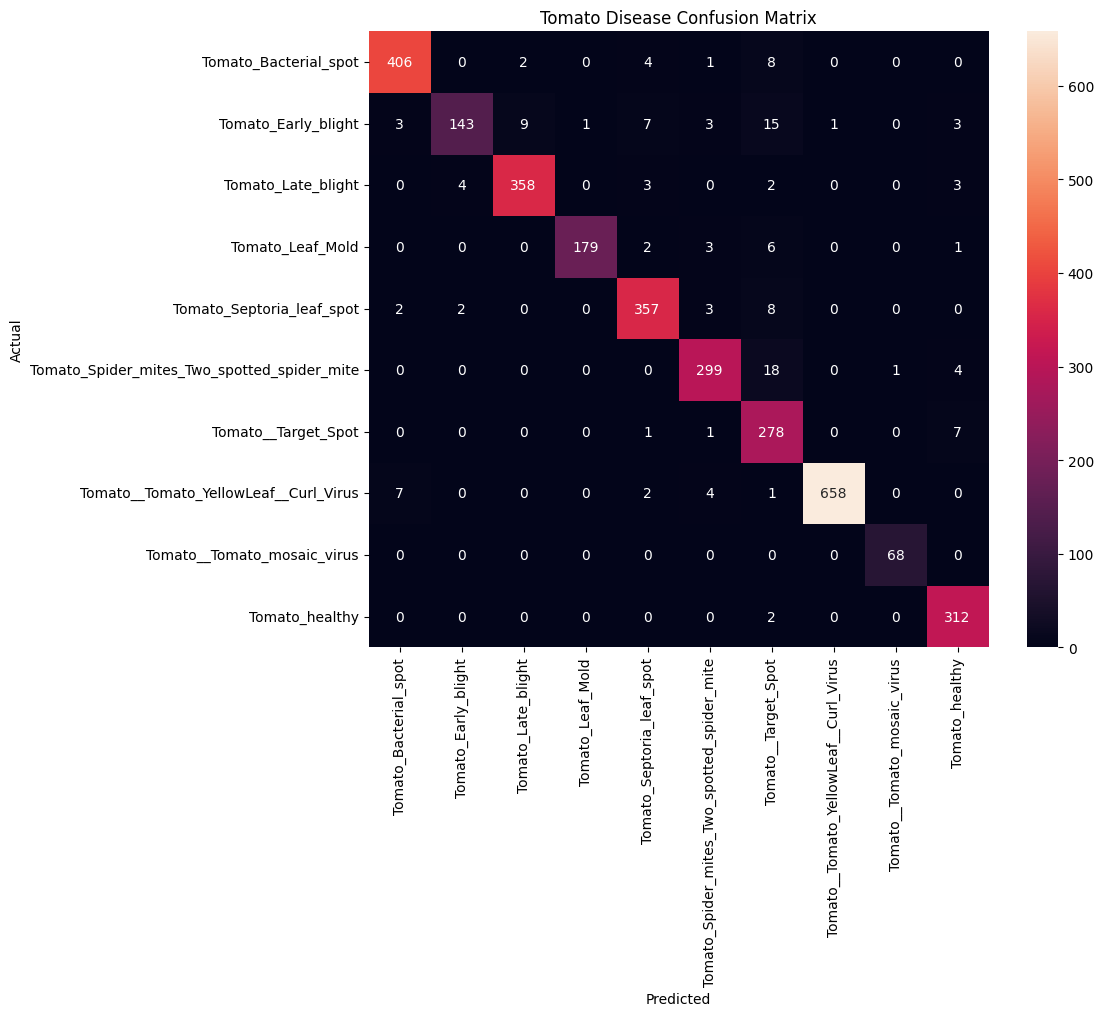

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tomato Disease Confusion Matrix")

plt.show()

In [29]:
img_path = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_healthy/0a0a0.jpg"

In [31]:
import os

folder_path = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_healthy"

files = os.listdir(folder_path)

print(files[:10])   # show first 10 images

['4a1e2b71-992a-4a64-a599-b49b8fa75378___RS_HL 0627.JPG', '7890f4dc-0c55-454b-ab23-3b25d3d973c4___GH_HL Leaf 366.1.JPG', 'beb8ecc5-3283-430e-b598-343f6754a752___GH_HL Leaf 328.JPG', '64b5d77e-2b06-461d-94f9-5f15250a7e77___GH_HL Leaf 505.1.JPG', 'df35d1fb-978c-4aeb-9d6f-e7da242c81b8___RS_HL 0515.JPG', 'a05f8f2d-6ac6-45d8-b7ad-394bbda892fc___RS_HL 0613.JPG', '53471454-9f9a-4182-91a3-c2c6c1268c56___RS_HL 0209.JPG', '93c9da62-19ca-4e90-b355-0dc71ff5cc4b___RS_HL 9752.JPG', 'e70e9a4c-481d-4c9c-8130-aff356057803___RS_HL 9661.JPG', '0de569a8-21c5-4d22-b9c9-ba0ef0f2b614___RS_HL 0314.JPG']


In [32]:
img_path = os.path.join(folder_path, files[0])

print("Testing image:", img_path)

Testing image: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_healthy/4a1e2b71-992a-4a64-a599-b49b8fa75378___RS_HL 0627.JPG


In [33]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [34]:
prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]

confidence = prediction[0][predicted_index] * 100

print("Predicted Disease:", predicted_class)
print("Confidence:", confidence, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step
Predicted Disease: Tomato_Late_blight
Confidence: 99.999146 %


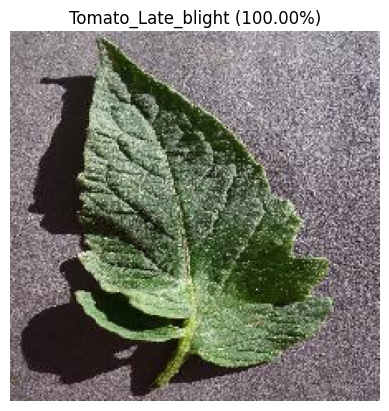

In [35]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()